In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [2]:
import warnings
warnings.filterwarnings(action = 'ignore')

# <font color='red'>ch01_허깅페이스</font>
- Transformers 라이브러리 내 pipeline()함수
- INference API : 발부 받은 key를 사용
## 1. 텍스트 기반 감정 분석(긍정/부정)

In [3]:
from transformers import pipeline

In [4]:
classifier = pipeline(task = 'text-classification',
                     model="distilbert-base-uncased-finetuned-sst-2-english")
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [8]:
classifier('이 영화는 정말 최고였어요, 감동적이고 연기가 대단해요')

[{'label': 'POSITIVE', 'score': 0.9054417610168457}]

In [9]:
result = classifier(["I've been waiting for a HuggingFace course my whole life.",
                     "I hate this so much!"])
[r.get('label') for r in result]

['POSITIVE', 'NEGATIVE']

## 2. 제로-샷 분류(zero-shot-classification)
- 비지도학습(군집분류)

In [16]:
classifier = pipeline(task = 'sentiment-analysis',
                     model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use cpu


In [17]:
classifier(["I've been waiting for a HuggingFace course my whole life.",
            "I hate this so much!"])

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

In [19]:
classifier = pipeline(task = 'zero-shot-classification',
                     model = 'facebook/bart-large-mnli')
classifier("I have a prblem with my iphone that needs to be resolved asap!!",
          candidate_labels =['phone','urgent','tablet','computer'])

Device set to use cpu


{'sequence': 'I have a prblem with my iphone that needs to be resolved asap!!',
 'labels': ['phone', 'urgent', 'computer', 'tablet'],
 'scores': [0.5059282183647156,
  0.4734128415584564,
  0.01765393279492855,
  0.003004995407536626]}

## 3. text 생성

In [20]:
generator = pipeline(task = 'text-generation',
                    model = "gpt2") # 허깅페이스 gpt2까지

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [22]:
generator("In this course. We will teach you how to",
         pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': 'In this course. We will teach you how to write code with HTML, CSS, JavaScript and jQuery.\n\nIf you want to be a master of your craft in JavaScript, check out our JavaScript Tutorials.\n\nWhat We\'re Building\n\nIf you missed the recent announcement that we were going to release JavaScript 5.0, now is the time to get to work.\n\nWe have released a small rewrite of the codebase. We\'ve added a little bit of bug fixes and optimization, but it\'s not very big. We want to make sure we make the code easier for you.\n\nIn the meantime, you can download the following HTML document:\n\n<a href="https://codepen.io/js-5.0.html">\n\n<br />\n\n<div class="js-5-0-0" style="width: 200px;" type="text/css">\n\n</div>\n\n<div style="width: 200px;" type="text/css">\n\n</div>\n\n</div>\n\nIt is also worth noting that for this project, we are using a different version of Babel which has been tested in a number of browsers. So in some cases, the code may need to be rewritten in the'}]

In [23]:
generator("이 과정은 다음과 같은 방법을 알려준다",
         pad_token_id=generator.tokenizer.eos_token_id)

[{'generated_text': '이 과정은 다음과 같은 방법을 알려준다."\n\n"I really mean that. You can\'t come here and be a dictator."\n\n"You\'re not dictator."\n\n"The most important thing is that you don\'t come here to be a dictator."\n\n"I don\'t care about your future. I\'m just going to keep working."\n\n"I\'m just going to keep fighting because I\'m going to do it."\n\n"The only way to keep fighting is to fight because you have people who are going to fight for you and I\'m going to keep fighting because you do give people that fight. I\'ll fight for you."\n\n"I\'ll fight for you because you\'re going to show us how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are because I\'m going to show you how big you are."\n\n"You\'re going to show us how big you are because I\'m going to show you how big you are because I\'m going to show you how big you are."\n\n

## 4. 마스크 채우기

In [24]:
unmasker = pipeline(task = 'fill-mask',
                   model = 'distilbert/distilroberta-base')

No model was supplied, defaulted to distilbert/distilroberta-base and revision fb53ab8 (https://huggingface.co/distilbert/distilroberta-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of the model checkpoint at distilbert/distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [26]:
unmasker("I'm going to hospital and meet a <mask>")

[{'score': 0.19275875389575958,
  'token': 3299,
  'token_str': ' doctor',
  'sequence': "I'm going to hospital and meet a doctor"},
 {'score': 0.06794668734073639,
  'token': 27321,
  'token_str': ' psychiatrist',
  'sequence': "I'm going to hospital and meet a psychiatrist"},
 {'score': 0.06435622274875641,
  'token': 16308,
  'token_str': ' surgeon',
  'sequence': "I'm going to hospital and meet a surgeon"},
 {'score': 0.05912911519408226,
  'token': 9008,
  'token_str': ' nurse',
  'sequence': "I'm going to hospital and meet a nurse"},
 {'score': 0.05705659091472626,
  'token': 1441,
  'token_str': ' friend',
  'sequence': "I'm going to hospital and meet a friend"}]

In [27]:
unmasker = pipeline(task='fill-mask',
                    model = "google-bert/bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at google-bert/bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu


In [34]:
unmasker("Hello, I'm a [MASK] model!",top_k=5)

[{'score': 0.22209393978118896,
  'token': 4827,
  'token_str': 'fashion',
  'sequence': "hello, i ' m a fashion model!"},
 {'score': 0.10136512666940689,
  'token': 3565,
  'token_str': 'super',
  'sequence': "hello, i ' m a super model!"},
 {'score': 0.07041735202074051,
  'token': 2535,
  'token_str': 'role',
  'sequence': "hello, i ' m a role model!"},
 {'score': 0.048954229801893234,
  'token': 2047,
  'token_str': 'new',
  'sequence': "hello, i ' m a new model!"},
 {'score': 0.03056986629962921,
  'token': 2944,
  'token_str': 'model',
  'sequence': "hello, i ' m a model model!"}]

In [40]:
# 다국어지원 모델이나 한글 지원이 만족스럽지 않을 수 있음
unmasker = pipeline('fill-mask',
                   'bert-base-multilingual-cased')

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [47]:
unmasker('안녕[MASK]세요')

[{'score': 0.3756418526172638,
  'token': 117,
  'token_str': ',',
  'sequence': '안녕, 세요'},
 {'score': 0.04108152911067009,
  'token': 14523,
  'token_str': '##해',
  'sequence': '안녕해 세요'},
 {'score': 0.03622591495513916,
  'token': 118,
  'token_str': '-',
  'sequence': '안녕 - 세요'},
 {'score': 0.03401370719075203,
  'token': 119,
  'token_str': '.',
  'sequence': '안녕. 세요'},
 {'score': 0.023117199540138245,
  'token': 48549,
  'token_str': '##요',
  'sequence': '안녕요 세요'}]

In [4]:
import dotenv
import os

In [6]:
dotenv.load_dotenv()
KEY=os.getenv("HF_TOKEN")

In [13]:
from huggingface_hub import InferenceClient
client = InferenceClient(provider='hf-inference',
                        api_key = os.environ['HF_TOKEN'])
client.fill_mask("Hello, I'm a [MASK] model",
                model = 'google-bert/bert-base-uncased',
                top_k = 2)

[FillMaskOutputElement(score=0.06705852597951889, sequence="hello, i ' m a fashion model", token=4827, token_str='fashion', fill_mask_output_token_str=None),
 FillMaskOutputElement(score=0.05897260084748268, sequence="hello, i ' m a new model", token=2047, token_str='new', fill_mask_output_token_str=None)]

In [14]:
unmasker = pipeline('fill-mask',
                   model = "bert-base-multilingual-cased")

Some weights of the model checkpoint at bert-base-multilingual-cased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [15]:
unmasker('안녕하세요? 나는 [MASK] 모델입니다.',top_k=3)

[{'score': 0.15278075635433197,
  'token': 9638,
  'token_str': '이',
  'sequence': '안녕하세요? 나는 이 모델입니다.'},
 {'score': 0.10853561013936996,
  'token': 62592,
  'token_str': '여자',
  'sequence': '안녕하세요? 나는 여자 모델입니다.'},
 {'score': 0.07730673253536224,
  'token': 108399,
  'token_str': '가수',
  'sequence': '안녕하세요? 나는 가수 모델입니다.'}]

## 5. 개체명 인식(NER : Named Entity REcognition)

In [16]:
new = pipeline(task="ner")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [19]:
new("My name is Sylvia and I work at Facebook in Brooklyn") # PER -> person, ORG - organism LOC -> location

[{'entity': 'I-PER',
  'score': 0.9982816,
  'index': 4,
  'word': 'Sylvia',
  'start': 11,
  'end': 17},
 {'entity': 'I-ORG',
  'score': 0.9977198,
  'index': 9,
  'word': 'Facebook',
  'start': 32,
  'end': 40},
 {'entity': 'I-LOC',
  'score': 0.99428236,
  'index': 11,
  'word': 'Brooklyn',
  'start': 44,
  'end': 52}]

## 6. 질의응답

In [20]:
question_answer = pipeline("question-answering",
                          "distilbert-base-cased-distilled-squad")

Device set to use cpu


In [21]:
question_answer(
                question = "Where do I work?",
                context = "My name is Sylvia and I work at Facebook in Brooklyn")

{'score': 0.6155391335487366, 'start': 32, 'end': 40, 'answer': 'Facebook'}

In [22]:
context = "My name is Sylvia and I work at Facebook in Brooklyn"
context[32:40]

'Facebook'

## 7. 문서 요약
- 현재 torch 2.5.1, 안정적인 버젼은 2.6이상일 때 

In [23]:
import torch
torch.__version__

'2.5.1'

In [24]:
summarizer = pipeline("summarization",
                          model = 'facebook/bart-large-cnn')

Device set to use cpu


In [25]:
summarizer('''Trump claims a ‘forever’ peace in the land of forever wars — but is it all one big illusion?
Analysis by CNN's Stephen Collinson
So much for the quagmire.
Donald Trump seems to have emerged from the worst crisis in America’s estrangement with Iran’s Islamic Republic with a win.
The president leaped on Tehran’s modest missile response Monday to the US pounding of its nuclear sites as a sign it wants to end escalations. “CONGRATULATIONS WORLD, ITS TIME FOR PEACE!” he posted on Truth Social.
Trump’s exuberance was a sign that he sees the US involvement in the conflict as over, at least for now.
And he followed up by announcing a ceasefire between Iran and Israel due to come into force later Tuesday. Ceasefires in the Middle East are often fragile and fleeting, as was underscored by attacks by both Israel and Iran in the hours before the truce was due to be established.
But the president was already trumpeting his chosen image as a peacemaker and consummate deal maker, only 48 hours after US stealth bombers slammed Iran.
“I think the ceasefire is unlimited. It’s going to go forever,” Trump told NBC News on Monday night, predicting that Israel and Iran will never “be shooting at each other again.”
That’s a bold claim given the Middle East’s reputation as a graveyard of American presidencies. And for all Trump’s marketing skills, events will decide whether his breakthrough is for real or just another illusion.
Read more here.''', max_length = 150, # 150자 이내로 줄여줘
                    min_length = 30, # 30자 초과
                    do_sample = False, # True면 창의적인 답변
                   
          )

[{'summary_text': 'Donald Trump claims a ‘forever’ peace in the land of forever wars — but is it all one big illusion? So much for the quagmire. Trump’s exuberance was a sign that he sees the US involvement in the conflict as over.'}]

In [30]:
summarizer('''He stated, “As someone who has been involved in artificial intelligence research and development in the industrial field, I am deeply honored to be able to contribute my experience and expertise to the development of South Korea.” He added, “I will do my utmost to fulfill President Lee Jae-myung’s first campaign promise of making South Korea one of the world’s top three AI powers and to promote genuine growth based on science and technology.”

When asked about the area of AI policy that he would prioritize, he replied, “AI must be integrated into all industries and technology fields to the extent that it is impossible to specify a particular area.” He added, “It is important to first apply AI to all fields and create an environment where all citizens can utilize AI effectively.”

On the scale of AI investment, he emphasized, “The answer lies in whether we will create AI that can only be used in Korea or challenge the global level. To reach the global level, more investment is necessary.”

On science and technology fields other than AI, he said, “As AI and basic science research have been combined to produce world-class technologies such as AlphaFold and RosettaFold, we will play a role in connecting basic science and the AI ecosystem to achieve results in the bio and manufacturing fields.”

He added, “With our experience in various telecommunications companies, we will also be able to play a sufficient role in the information and communications technology (ICT) field.”

Translated with DeepL.com (free version)'''
           , max_length = 150, # 150자 이내로 줄여줘
             min_length = 100, # 30자 초과
             do_sample = False, # True면 창의적인 답변
                   
          )

[{'summary_text': "He added, “I will do my utmost to fulfill President Lee Jae-myung’s first campaign promise of making South Korea one of the world's top three AI powers.” He emphasized, ‘The answer lies in whether we will create AI that can only be used in Korea or challenge the global level. To reach theglobal level, more investment is necessary.’ He also said that as AI and basic science research have been combined to produce world-class technologies, we will play a role in connecting basic science and the AI ecosystem."}]

## 8. 번역하기

In [34]:
# 한->영
ko2en = pipeline('translation', model="Helsinki-NLP/opus-mt-ko-en")
       
# 영->한(?)
en2ko = pipeline('translation', model="Helsinki-NLP/opus-mt-tc-big-en-ko")

All model checkpoint layers were used when initializing TFMarianMTModel.

All the layers of TFMarianMTModel were initialized from the model checkpoint at Helsinki-NLP/opus-mt-ko-en.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFMarianMTModel for predictions without further training.
Device set to use 0
Device set to use cpu


In [40]:
ko_sentence = "이 문장을 영어로 번역해주세요"
en_sentence = "I enjoy learning about AI"
ko_result = ko2en(ko_sentence)[0].get('translation_text')
en_result = en2ko(en_sentence)[0].get('translation_text')
print('한글말 -> 영어 :',ko_result)
print('영어 -> 한글말 :',en_result)

한글말 -> 영어 : Please translate this sentence into English.
영어 -> 한글말 : US  풍선 행


In [49]:
result = ko2en([
    "이 문장을 영어로 번역해 주세요",
    "내일은 드디어 LLM 시작!",
    "기계학습과 깊은학습 평가가 있어요"
])

In [50]:
print('\n'.join([r.get('translation_text') for r in result]))

Please translate this sentence into English.
Tomorrow, we're finally starting the LLM!
There's machine learning and deep learning evaluations.


## 9. 이미지를 설명하는 텍스트를 생성

In [51]:
imgtotext = pipeline(task = 'image-to-text')

No model was supplied, defaulted to ydshieh/vit-gpt2-coco-en and revision 5bebf1e (https://huggingface.co/ydshieh/vit-gpt2-coco-en).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/4.34k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/982M [00:00<?, ?B/s]

tf_model.h5:   0%|          | 0.00/957M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/982M [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/120 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use 0


In [54]:
url = "https://huggingface.co/datasets/Narsil/image_dummy/resolve/main/parrots.png"
from PIL import Image
import requests
img = Image.open(requests.get(url, stream = True).raw)
small_img = img.resize((150,150))

In [55]:
imgtotext(url, max_new_tokens=30)

[{'generated_text': 'two birds are standing next to each other '}]

In [56]:
type(img),type(small_img)

(PIL.PngImagePlugin.PngImageFile, PIL.Image.Image)

In [57]:
imgtotext(img)

[{'generated_text': 'two birds are standing next to each other '}]

In [58]:
imgtotext('images/dogcat.jpg')

[{'generated_text': 'a small dog and a large dog are sitting together '}]

In [59]:
imgtotext('images/fruits.jpeg')

[{'generated_text': 'a fruit and vegetable stand with bananas, oranges, and apples '}]

## 10. 이미지 분류하기

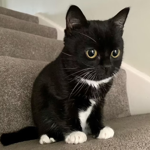

In [64]:
image = Image.open('images/cat.jpg')
image.resize((150,150))

In [62]:
imgclassifier = pipeline(task = "image-classification",
                        model="google/vit-base-patch16-224")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cpu


In [66]:
imgclassifier(image)

[{'label': 'Egyptian cat', 'score': 0.853131890296936},
 {'label': 'tabby, tabby cat', 'score': 0.04750382527709007},
 {'label': 'tiger cat', 'score': 0.03486616536974907},
 {'label': 'Persian cat', 'score': 0.007555846590548754},
 {'label': 'Siamese cat, Siamese', 'score': 0.003788590431213379}]

In [68]:
imgclassifier('images/다운로드.jpg')

[{'label': 'suit, suit of clothes', 'score': 0.42150428891181946},
 {'label': 'abaya', 'score': 0.24637529253959656},
 {'label': 'maillot', 'score': 0.03536376729607582},
 {'label': "academic gown, academic robe, judge's robe",
  'score': 0.016049299389123917},
 {'label': 'trench coat', 'score': 0.015461700968444347}]